<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Project 1 -  Deep pricing and calibration of the Heston model </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>


# <font color='red'>PLEASE ENTER YOUR FULL NAMES HERE:</font>

- Romain ETIENNE
- John DOE

<font color='red'>**DEADLINE: March 4, 2026 (5:00 pm)**</font>

<font color='red'>**Please send both pdf and ipynb files with name : Name1_Name2_Project1**</font>


# 0. Setup

In [1]:
# --- Imports & global settings ---
import os, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import norm
from scipy.optimize import minimize
from time import perf_counter
import datetime
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
# Training with early stopping on validation RMSE
os.makedirs("Data", exist_ok=True)
file_save_best_model = "Data/best_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED=0
np.random.seed(SEED)
torch.manual_seed(SEED)

# The Heston stochastic volatility model


The Heston Model (Heston, 1993) under the risk-neutral measure $\mathbb{Q}$:

\begin{equation}
  \begin{aligned}
    \frac{dS_t}{S_t} &= r\, dt + \sqrt{v_t}\, dW_t,\\
    dv_t &= \alpha(\beta - v_t)\, dt + \delta \sqrt{v_t}\, dB_t,\\
    d\langle W,B\rangle_t &= \rho\, dt.
  \end{aligned}
\end{equation}

We calibrate the parameter vector $\Theta=(v_0,\alpha,\beta,\delta,\rho)$.

The Heston model is well adapted to fit the volatiliy smile: Heston model's parameters can adapt lots of smile shapes.






We consider **European call options** with payoff $(S_T-K)^+$.  
In this project, calibration is performed **on call prices** (as in your Chapter 3 tutorials), not on implied volatilities.

You will use a neural network surrogate fast pricer:
$$
(\Theta, K) \mapsto C_{\text{Heston}}(K,T)
$$
for a **single maturity** $T$ (same setting as your market dataset).


# Your task

Inspired by your Chapter 3 notebooks (FastPricing_BS_Surrogate and Calibration_NN):

1) Generate simulations of the Heston model
2) Implement the Heston pricer (via Monte Carlo) to generate synthetic training data
3) Train a deep fast pricer on the synthetic data and check performance
4) Train a deep fast pricer
5) Analyze the results and find out what was wrong in the procedure

# Monte Carlo simulation under the Heston model

In this project, we simulate asset price trajectories under the Heston stochastic volatility model
in order to compute option prices via Monte Carlo.


## Time discretization

We discretize time:

$$
t_n = n \Delta t, \quad \Delta t = \frac{T}{N}.
$$

We consider correlated Brownian increments:

$$
\begin{aligned}
\Delta W_n &= \sqrt{\Delta t}\, Z_1^n, \\
\Delta B_n &= \sqrt{\Delta t}\left( \rho Z_1^n + \sqrt{1-\rho^2} Z_2^n \right).
\end{aligned}
$$

with $ Z_1^n, Z_2^n \sim \mathcal{N}(0,1) $


---

## Variance discretization

A simple Euler scheme gives:

$$
v_{n+1} = v_n + \alpha(\beta - v_n)\Delta t
          + \delta \sqrt{v_n}\, \Delta B_n.
$$

However, this may produce negative values. A common practical fix is the **Full Truncation Euler scheme**:

$$
v_{n+1} = v_n + \alpha(\beta - v_n^+)\Delta t
          + \delta \sqrt{v_n^+}\, \Delta B_n,
$$

with $v_n^+ = \max(v_n, 0).$


---

## Stock price discretization

Using a log-Euler scheme:

$$
S_{n+1} =
S_n \exp\left(
(r - \tfrac{1}{2} v_n^+)\Delta t
+ \sqrt{v_n^+}\, \Delta W_n
\right).
$$


<span style="color: red;">**2.1** Implement a function that generates trajectories from the Heston model.</span>


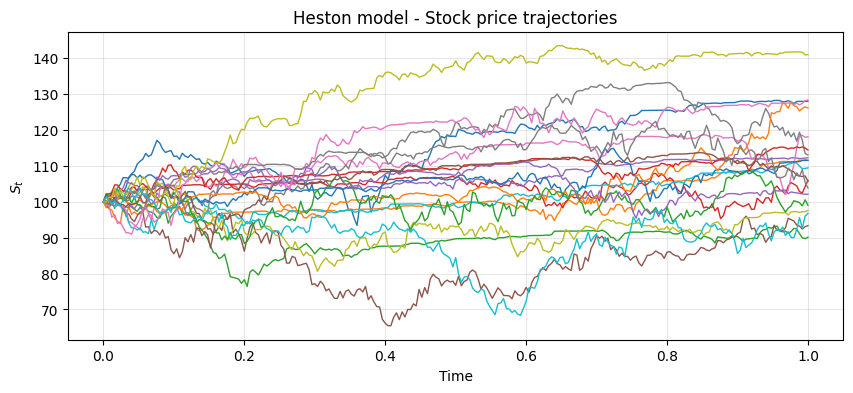

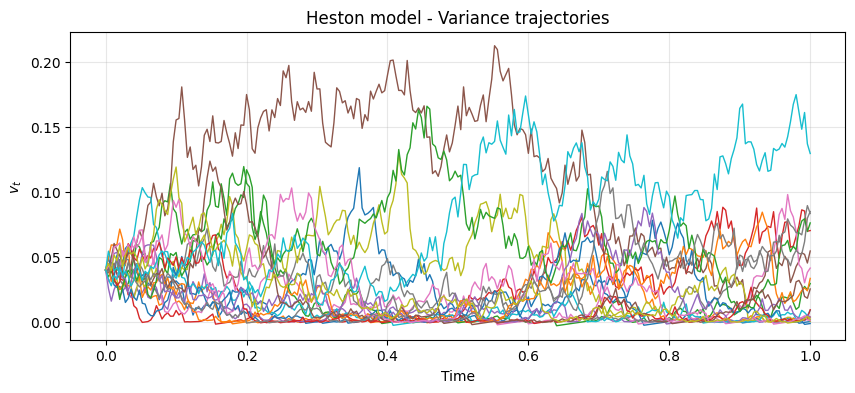

In [3]:
def simulate_heston(S0,v0,r,alpha,beta,delta,rho,T,n_steps,n_paths):
    """
    Simulate trajectories under the Heston model:
        dS_t / S_t = r dt + sqrt(v_t) dW_t
        dv_t = alpha (beta - v_t) dt + delta sqrt(v_t) dB_t
        d<W,B>_t = rho dt
    using Full Truncation Euler scheme.

    Outputs
    -------
    S : array (n_paths, n_steps+1)
    v : array (n_paths, n_steps+1)
    """

    dt = T / n_steps

    S_paths = np.zeros((n_paths, n_steps + 1))
    v_paths = np.zeros((n_paths, n_steps + 1))

    S_paths[:, 0] = S0
    v_paths[:, 0] = v0

    for t in range(n_steps):
        Z1 = np.random.standard_normal(n_paths)
        Z2 = np.random.standard_normal(n_paths)

        # Correlated Brownian increments
        dW = np.sqrt(dt) * Z1
        dB = np.sqrt(dt) * (rho * Z1 + np.sqrt(1 - rho**2) * Z2)

        # Full Truncation: use v+ = max(v, 0) in drift and diffusion
        v_pos = np.maximum(v_paths[:, t], 0.0)

        # Variance update (Full Truncation Euler)
        v_paths[:, t+1] = v_paths[:, t] + alpha * (beta - v_pos) * dt + delta * np.sqrt(v_pos) * dB

        # Stock price update (log-Euler)
        S_paths[:, t+1] = S_paths[:, t] * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos) * dW)

    return S_paths, v_paths



# Parameters
S0 = 100
v0 = 0.04
r = 0.02
alpha = 2.0
beta = 0.04
delta = 0.6
rho = -0.7
T = 1.0

n_steps = 250
n_paths = 20

# Simulate
S_paths, v_paths = simulate_heston(
    S0, v0, r,
    alpha, beta, delta, rho,
    T, n_steps, n_paths,
)

# Time grid
t_grid = np.linspace(0, T, n_steps + 1)

# Plot stock paths
plt.figure(figsize=(10,4))
for i in range(n_paths):
    plt.plot(t_grid, S_paths[i], lw=1)
plt.title("Heston model - Stock price trajectories")
plt.xlabel("Time")
plt.ylabel("$S_t$")
plt.grid(alpha=0.3)
plt.show()

# Plot variance paths
plt.figure(figsize=(10,4))
for i in range(n_paths):
    plt.plot(t_grid, v_paths[i], lw=1)
plt.title("Heston model - Variance trajectories")
plt.xlabel("Time")
plt.ylabel("$v_t$")
plt.grid(alpha=0.3)
plt.show()


# 3. Call option price and dataset generation

Now it is possible to approximate call option prices by Monte Carlo

<span style="color: red;">**3.1** Implement a function that generates trajectories from the Heston model.</span>

In [4]:
def heston_call_price_mc(S0, v0, r, alpha, beta, delta, rho, T, K, n_steps, n_paths):
    """
    Price a European call option under the Heston model via Monte Carlo.

    Parameters
    ----------
    S0, v0, r, alpha, beta, delta, rho : Heston model parameters
    T  : maturity
    K  : strike
    n_steps : number of time steps
    n_paths : number of Monte Carlo paths

    Returns
    -------
    price : float, discounted expected payoff
    """
    S_paths, _ = simulate_heston(S0, v0, r, alpha, beta, delta, rho, T, n_steps, n_paths)

    # Terminal stock prices
    S_T = S_paths[:, -1]

    # Discounted expected payoff
    payoff = np.maximum(S_T - K, 0.0)
    price = np.exp(-r * T) * np.mean(payoff)

    return price


## 3.1 Dataset generation

The objective is to randomly sample Heston parameters in the training domain 
$\mathcal{D}_{\text{domain}}$:

- $v_0 \in [0.01, 0.12]$
- $\alpha \in [0.3, 4.0]$
- $\beta \in [0.01, 0.12]$
- $\delta \in [0.1, 1.2]$
- $\rho \in [-0.95, -0.05]$
- $S_0 = 274.73$
- $K \in [60, 140]$
- $T  = 0.2$


For each $x \in \mathcal{D}_{\text{domain}}$, we then compute Monte Carlo prices $y$ 
using the Heston simulation scheme implemented previously.

The surrogate model will therefore learn the mapping:

$$
(v_0, \alpha, \beta, \delta, \rho, S_0, K, T)
\;\longmapsto\;
C_{\text{Heston}}(S_0,K,T).
$$

<span style="color: red;"> **3.1** Implement a function `build_dataset(n_samples, n_simulations)` that builds a dataset $(x_i, y_i) \in \mathcal{D}_{\text{domain}}$, for $i = 1, \dots, n_{\text{samples}}$</span>

<span style="color: red;">**3.2** Use this function to generate a dataset of 10,000 samples, and split the dataset into $X_{\text{train}}, y_{\text{train}}, X_{\text{val}}, y_{\text{val}}, X_{\text{test}}, y_{\text{test}}$  with a respective repartition (50%, 10%, 40%).</span>

In [5]:
# ------------------------------------------
# Dataset builder
# ------------------------------------------

def build_dataset(n_samples, n_paths, n_steps=100):
    """
    Build a dataset of (features, MC price) pairs by sampling Heston parameters
    uniformly from the training domain D_domain.

    Features: [v0, alpha, beta, delta, rho, S0, K, T]
    Target   : MC call price
    """

    # Fixed parameters
    S0_fixed = 274.73
    T_fixed  = 0.2
    r_fixed  = 0.01  # risk-free rate as previous Labs

    X = np.zeros((n_samples, 8))
    y = np.zeros((n_samples, 1))

    t0 = perf_counter()
    for i in range(n_samples):
        # Uniformly sample Heston parameters from D_domain
        v0    = np.random.uniform(0.01, 0.12)
        alpha = np.random.uniform(0.3,  4.0)
        beta  = np.random.uniform(0.01, 0.12)
        delta = np.random.uniform(0.1,  1.2)
        rho   = np.random.uniform(-0.95, -0.05)
        K     = np.random.uniform(60.0, 140.0)

        X[i] = [v0, alpha, beta, delta, rho, S0_fixed, K, T_fixed]
        y[i] = heston_call_price_mc(
            S0_fixed, v0, r_fixed, alpha, beta, delta, rho,
            T_fixed, K, n_steps, n_paths
        )

        if (i + 1) % max(1, n_samples // 10) == 0:
            elapsed = perf_counter() - t0
            print(f"  {i+1}/{n_samples} done  ({elapsed:.1f}s elapsed)")

    print(f"Dataset generated in {perf_counter()-t0:.1f}s")
    return X, y

# Generate dataset
X, y = build_dataset(n_samples=10000, n_paths=5000, n_steps=50)


  1000/10000 done  (11.4s elapsed)
  2000/10000 done  (22.3s elapsed)
  3000/10000 done  (33.3s elapsed)
  4000/10000 done  (45.0s elapsed)
  5000/10000 done  (56.5s elapsed)
  6000/10000 done  (67.7s elapsed)
  7000/10000 done  (78.8s elapsed)
  8000/10000 done  (90.2s elapsed)
  9000/10000 done  (101.9s elapsed)
  10000/10000 done  (113.7s elapsed)
Dataset generated in 113.7s


In [6]:
# ------------------------------------------
# Train / Val / Test split  (50% / 10% / 40%)
# ------------------------------------------


def random_split(X, y, train_ratio=0.5, val_ratio=0.1):
    """
    Randomly split (X, y) into train / val / test sets.
    test_ratio = 1 - train_ratio - val_ratio
    """
    n = len(X)
    idx = np.random.permutation(n)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    idx_train = idx[:n_train]
    idx_val = idx[n_train : n_train + n_val]
    idx_test = idx[n_train + n_val :]

    return (
        (X[idx_train], y[idx_train]),
        (X[idx_val], y[idx_val]),
        (X[idx_test], y[idx_test]),
    )


(X_train, y_train), (X_val, y_val), (X_test, y_test) = random_split(X, y)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (5000, 8)
Val  : (1000, 8)
Test : (4000, 8)


## 3.2 Data normalization

<span style="color: red;"> **3.3** Standardize all the data in an appropriate way</span>


In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Save scalers as previous labs
joblib.dump(scaler_X, "Data/scaler_X.joblib")
joblib.dump(scaler_y, "Data/scaler_y.joblib")

print("X_train mean (approx):", X_train_s.mean(axis=0).round(3))
print("X_train std  (approx):", X_train_s.std(axis=0).round(3))
print("y_train mean (approx):", y_train_s.mean().round(3))
print("y_train std  (approx):", y_train_s.std().round(3))

# Build PyTorch TensorDatasets and DataLoaders
def make_loader(X_s, y_s, batch_size=256, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_s, dtype=torch.float32),
        torch.tensor(y_s, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train_s, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val_s,   shuffle=False)
test_loader  = make_loader(X_test_s,  y_test_s,  shuffle=False)

print("\nDataLoaders ready.")


X_train mean (approx): [ 0. -0. -0.  0.  0.  0.  0. -0.]
X_train std  (approx): [1. 1. 1. 1. 1. 0. 1. 0.]
y_train mean (approx): -0.0
y_train std  (approx): 1.0

DataLoaders ready.


## 4. Surrogate model: a simple MLP

Now that all is ready to train a Neural Network, we consider a simple MLP surrogate model.

We propose a fully-connected network:
- **input dim:** 5 (features $(v_0, \alpha, \beta, \delta, \rho, S_0, K, T)$ standardized)
- **Hidden layers:** 3 layers with sizes 128 --> 128 --> 64, all with ReLU
- **Output dim:** 1 (scaled (standardized) price)
- **Loss function:** MSE (nn.MSELoss)
- **Optimizer:** Adam (Learning rate $1e^{-3}$)

<span style="color: red;">**4.1** Build the class MLP with the above characteristics  </span>

<span style="color: red;">**4.2** Implement the function `run_epoch(loader, train)` that runs one epoch</span>
- <span style="color: red;">sets model.train() if train=True otherwise model.eval()</span>
- <span style="color: red;">iterates over the loader, sends</span>
- <span style="color: red;">returns the losses </span>

<span style="color: red;">**4.3** Implement the training procedure on 250 Epochs, with an overfitting control  </span>
- <span style="color: red;">with a patience counter of 20 (if no loss decrease during 20 Epochs, then stop</span>
- <span style="color: red;">save the best model in `Data/best_mlp.pt`</span>

<span style="color: red;">**4.4** Plot the MSE losses (Learning Curves) for the train and val sets  </span>

In [8]:
# --------------------------------------------------
# 4.1  MLP architecture
# --------------------------------------------------
class MLP(nn.Module):
    def __init__(self, in_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),    nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model    = MLP(in_dim=8).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [9]:
# --------------------------------------------------
# 4.2  One-epoch helper
# --------------------------------------------------
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    n_batches = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches


In [10]:
# --------------------------------------------------
# 4.3  Training loop with early stopping
# --------------------------------------------------
MAX_EPOCHS = 250
PATIENCE = 20

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), file_save_best_model)
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d} | train MSE: {tr_loss:.6f} | val MSE: {val_loss:.6f}"
            f"  (patience {patience_counter}/{PATIENCE})"
        )

    if patience_counter >= PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch}  (best val MSE = {best_val_loss:.6f})"
        )
        break

print(f"\nBest model saved to '{file_save_best_model}'")


Epoch   1 | train MSE: 0.488319 | val MSE: 0.040577  (patience 0/20)
Epoch  10 | train MSE: 0.001263 | val MSE: 0.001431  (patience 1/20)
Epoch  20 | train MSE: 0.000782 | val MSE: 0.001134  (patience 4/20)
Epoch  30 | train MSE: 0.000612 | val MSE: 0.000795  (patience 0/20)
Epoch  40 | train MSE: 0.000669 | val MSE: 0.000987  (patience 4/20)
Epoch  50 | train MSE: 0.000567 | val MSE: 0.000981  (patience 2/20)
Epoch  60 | train MSE: 0.000502 | val MSE: 0.000671  (patience 6/20)
Epoch  70 | train MSE: 0.000449 | val MSE: 0.000675  (patience 2/20)
Epoch  80 | train MSE: 0.000504 | val MSE: 0.000653  (patience 5/20)
Epoch  90 | train MSE: 0.000415 | val MSE: 0.000605  (patience 5/20)
Epoch 100 | train MSE: 0.000392 | val MSE: 0.000620  (patience 15/20)
Epoch 110 | train MSE: 0.000381 | val MSE: 0.000615  (patience 3/20)
Epoch 120 | train MSE: 0.000373 | val MSE: 0.000571  (patience 0/20)
Epoch 130 | train MSE: 0.000368 | val MSE: 0.000668  (patience 10/20)
Epoch 140 | train MSE: 0.000396 

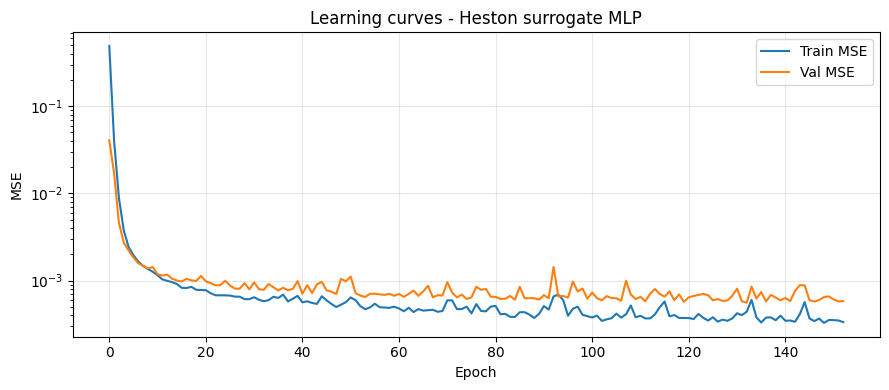

In [13]:
# --------------------------------------------------
# 4.4  Learning curves
# --------------------------------------------------
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label="Train MSE", lw=1.5)
plt.plot(val_losses, label="Val MSE", lw=1.5)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Learning curves - Heston surrogate MLP")
plt.legend()
plt.grid(alpha=0.3)
plt.yscale("log")
plt.tight_layout()
plt.show()

## 5. Evaluation (accuracy)

Now the surrogate model is trained, let's evaluate its performance on the test set

<span style="color: red;">**5.1** Load the best model saved in `file_save_best_model` and the scaling parameters with command `joblib.load` and evaluate with `model.eval()`</span>

<span style="color: red;">**5.2** Compute the predicted `y_test_pred` from X_test (test_loader tensor) and unscale to get `y_test_hat`</span>

<span style="color: red;">**5.3** Compute the MAE and RMSE, and give the scatter plot MC price vs. NN price </span>

<span style="color: red;">**5.4** Give the scatter plot BS price vs. NN price </span>

In [14]:
# --------------------------------------------------
# 5.1  Load best model + scalers
# --------------------------------------------------
scaler_X = joblib.load("Data/scaler_X.joblib")
scaler_y = joblib.load("Data/scaler_y.joblib")

model_eval = MLP(in_dim=8).to(device)
model_eval.load_state_dict(torch.load(file_save_best_model, map_location=device))
model_eval.eval()
print("Model loaded from", file_save_best_model)


Model loaded from Data/best_mlp.pt


In [15]:
# --------------------------------------------------
# 5.2  Predict on test set and unscale
# --------------------------------------------------
y_test_pred_list = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_batch_pred = model_eval(X_batch).cpu().numpy()
        y_test_pred_list.append(y_batch_pred)

y_test_pred = np.concatenate(y_test_pred_list, axis=0)  # scaled
y_test_hat = scaler_y.inverse_transform(y_test_pred)  # original price scale

# Ground-truth test prices (unscaled)
y_test_true = y_test  # already in original scale from random_split

Test MAE  : 0.4303
Test RMSE : 0.5450


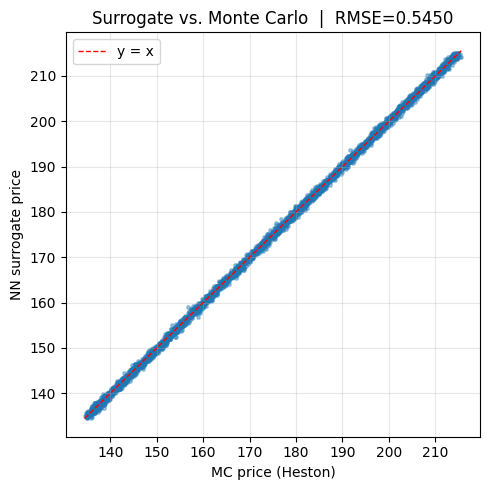

In [16]:
# --------------------------------------------------
# 5.3  MAE, RMSE and scatter plot MC vs. NN
# --------------------------------------------------
mae = np.mean(np.abs(y_test_hat - y_test_true))
rmse = np.sqrt(np.mean((y_test_hat - y_test_true) ** 2))
print(f"Test MAE  : {mae:.4f}")
print(f"Test RMSE : {rmse:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test_true, y_test_hat, s=6, alpha=0.4)
m = float(min(y_test_true.min(), y_test_hat.min()))
M = float(max(y_test_true.max(), y_test_hat.max()))
plt.plot([m, M], [m, M], "r--", lw=1, label="y = x")
plt.xlabel("MC price (Heston)")
plt.ylabel("NN surrogate price")
plt.title(f"Surrogate vs. Monte Carlo  |  RMSE={rmse:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


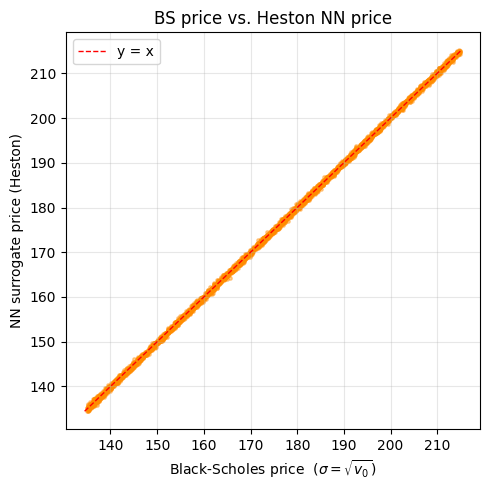


Deviation BS vs NN:
  MAE  = 0.2587
  RMSE = 0.3269


In [ ]:
# --------------------------------------------------
# 5.4  Scatter plot: Black-Scholes price vs. NN price
#
#  BS is computed with σ = sqrt(v0) as a rough equiv. vol.
#  This shows how much Heston and BS diverge on the test set
#  (the gap is the "volatility smile" captured by the NN).
# --------------------------------------------------
def black_scholes_call(S0, K, T, sigma, r):
    """Vectorised Black-Scholes call price."""
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return np.where(sigma > 0, price, np.maximum(S0 - K * np.exp(-r * T), 0.0))


r_fixed = 0.01
# From test features: [v0, alpha, beta, delta, rho, S0, K, T]
v0_test = X_test[:, 0]
S0_test = X_test[:, 5]
K_test = X_test[:, 6]
T_test = X_test[:, 7]
sigma_bs = np.sqrt(v0_test)  # ATM vol approximation: σ ≈ √v₀

y_bs = black_scholes_call(S0_test, K_test, T_test, sigma_bs, r_fixed).reshape(-1, 1)

plt.figure(figsize=(5, 5))
plt.scatter(y_bs, y_test_hat, s=6, alpha=0.4, color="darkorange")
m = float(min(y_bs.min(), y_test_hat.min()))
M = float(max(y_bs.max(), y_test_hat.max()))
plt.plot([m, M], [m, M], "r--", lw=1, label="y = x")
plt.xlabel("Black-Scholes price  ($\\sigma = \\sqrt{v_0}$)")
plt.ylabel("NN surrogate price (Heston)")
plt.title("BS price vs. Heston NN price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDeviation BS vs NN:")
print(f"  MAE  = {np.mean(np.abs(y_bs - y_test_hat)):.4f}")
print(f"  RMSE = {np.sqrt(np.mean((y_bs - y_test_hat)**2)):.4f}")

# 6 Calibration on real data

The objective is to calibrate the Black-Scholes model, i.e. to estimated the implied volatility $\sigma_\text{imp}$.

We propose to estimate $\theta = (v_0, \alpha, \beta, \delta, \rho)$ by minimizing the quadrati error:
\begin{equation}
\sigma_\text{imp} = \arg\min_{\theta} J^{method}(\theta) 
\end{equation}
with 
\begin{equation}
J^{method}(\theta)  = \frac{1}{I}\sum_{i=1}^I \| C^{mkt}_i - C^{NN}_i(\theta) \|^2
\end{equation}
where $C^{NN}_i(\sigma)$ is the price obtained from the NN Surrogate fast pricer. 





### 6.1 First step  : download and prepare the data

In [25]:
# Load AAPL calls (semicolon-separated)
df = pd.read_csv("Data/AAPL_Call.csv", sep=";", thousands=",")

print(f"df.head():\n{df.head()}")
print(f"df.columns: {list(df.columns)}")
print(f"df.shape: {df.shape}")

S0 = 274.73
r = 0.01

# Price = mid (bid/ask) 
C_mkt_series = (df["Bid"] + df["Ask"]) / 2.0

#else:
#C_mkt_series = df["Last Price"]

K_vec     = df["Strike"].to_numpy(dtype=float)
C_mkt_vec = C_mkt_series.to_numpy(dtype=float)


d = datetime.date(2025, 12, 26)
D = datetime.date(2026, 12, 18)
Tmt = (D - d).days / 365.0  # T in year
T_vec = np.full_like(K_vec, Tmt, dtype=float)

print(K_vec, T_vec)

df.head():
         Contract Name  Strike  Last Price     Bid     Ask  Change  Volume  \
0  AAPL261218C00005000       5      264.64  267.50  271.30     0.0     1.0   
1  AAPL261218C00010000      10      245.23  251.00  254.85     0.0    10.0   
2  AAPL261218C00015000      15      186.06  238.95  242.35     0.0     4.0   
3  AAPL261218C00020000      20      240.80  255.65  259.55     0.0     1.0   
4  AAPL261218C00025000      25      184.65  229.35  232.75     0.0     1.0   

   Open Interest  
0            2.0  
1           15.0  
2            5.0  
3            5.0  
4            2.0  
df.columns: ['Contract Name', 'Strike', 'Last Price', 'Bid', 'Ask', 'Change', 'Volume', 'Open Interest']
df.shape: (85, 8)
[  5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  60.  70.  80.  85.
  90.  95. 100. 105. 110. 115. 120. 125. 130. 135. 140. 145. 150. 155.
 160. 165. 170. 175. 180. 185. 190. 195. 200. 205. 210. 215. 220. 225.
 230. 235. 240. 245. 250. 255. 260. 265. 270. 275. 280. 285. 290. 295.

### 6.2 Cost function

<span style="color: red;">**6.1** Build in the code below the function `nn_price_call_heston` that computes the price from the NN Surrogate Fast pricer.</span>

In [ ]:
def build_features_heston(v0, alpha, beta, delta, rho, S0, K, T):
    '''
    Creates the NN input features for the Heston surrogate model.

    All inputs must be broadcastable arrays of same length.
    '''
    v0    = np.asarray(v0, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    beta  = np.asarray(beta, dtype=float)
    delta = np.asarray(delta, dtype=float)
    rho   = np.asarray(rho, dtype=float)
    S0    = np.asarray(S0, dtype=float)
    K     = np.asarray(K, dtype=float)
    T     = np.asarray(T, dtype=float)

    return np.stack([v0, alpha, beta, delta, rho, S0, K, T], axis=1)


def nn_price_call_heston(model, scaler_X, scaler_y, X):
    """
    Compute Heston call prices using the NN surrogate fast pricer.

    Parameters
    ----------
    model    : trained MLP (in eval mode)
    scaler_X : fitted StandardScaler for features
    scaler_y : fitted StandardScaler for prices
    X        : numpy array (N, 8) of raw features [v0,alpha,beta,delta,rho,S0,K,T]

    Returns
    -------
    prices : numpy array (N, 1) of call prices in original scale
    """
    X_scaled = scaler_X.transform(X)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        y_scaled = model(X_tensor).cpu().numpy()

    return scaler_y.inverse_transform(y_scaled)


def loss_nn_heston(theta):
    '''
    theta = [v0, alpha, beta, delta, rho]
    Uses global variables K_mkt, T_mkt, C_mkt, S0.
    '''

    v0, alpha, beta, delta, rho = theta

    X = build_features_heston(
        v0 * np.ones_like(K_mkt),  # type: ignore
        alpha * np.ones_like(K_mkt),  # type: ignore
        beta * np.ones_like(K_mkt),  # type: ignore
        delta * np.ones_like(K_mkt),  # type: ignore
        rho * np.ones_like(K_mkt),  # type: ignore
        S0 * np.ones_like(K_mkt),  # type: ignore
        K_mkt,  # type: ignore
        T_mkt,  # type: ignore
    )

    C = nn_price_call_heston(model_eval, scaler_X, scaler_y, X).reshape(-1)

    return float(np.mean((C - C_mkt) ** 2))  # type: ignore

### 6.3 Calibration: minimization procedure

<span style="color: red;">**6.2** Implement the minimization procedure to calibrate the Heston model .</span>

<span style="color: red;">**6.3** Compare in the same graph the observed and model prices .</span>




In [29]:
# ==============================
# Calibration Heston (global)
# ==============================

# Initial guess
theta_0 = np.array([0.04, 1.0, 0.04, 0.5, -0.5])

# Bounds
HES_BOUNDS = [
    (0.001, 0.2),     # v0
    (0.1, 5.0),       # alpha
    (0.001, 0.2),     # beta
    (0.05, 2.0),      # delta
    (-0.999, 0.999)   # rho
]

# Global variables used by loss_nn_heston
K_mkt = K_vec.copy()
T_mkt = T_vec.copy()
C_mkt = C_mkt_vec.copy()

In [30]:
# --------------------------------------------------
# 6.2  Minimisation
# --------------------------------------------------
t0_cal = perf_counter()
res = minimize(
    loss_nn_heston,
    x0=theta_0,
    method="L-BFGS-B",
    bounds=HES_BOUNDS,
    options={"maxiter": 500, "ftol": 1e-12, "gtol": 1e-8},
)
print(f"Calibration done in {perf_counter()-t0_cal:.2f}s  |  success: {res.success}")
print(f"Message: {res.message}")

theta_star = res.x
print("\nCalibrated parameters:")
print(f"  v0    = {theta_star[0]:.6f}")
print(f"  alpha = {theta_star[1]:.6f}")
print(f"  beta  = {theta_star[2]:.6f}")
print(f"  delta = {theta_star[3]:.6f}")
print(f"  rho   = {theta_star[4]:.6f}")
print(f"Final loss = {res.fun:.6f}")

# Vectorised NN prices at calibrated parameters over all market strikes
v0_star, alpha_star, beta_star, delta_star, rho_star = theta_star

X_cal = build_features_heston(
    v0_star * np.ones_like(K_vec),
    alpha_star * np.ones_like(K_vec),
    beta_star * np.ones_like(K_vec),
    delta_star * np.ones_like(K_vec),
    rho_star * np.ones_like(K_vec),
    S0 * np.ones_like(K_vec),
    K_vec,
    T_vec,
)
C_nn = nn_price_call_heston(model_eval, scaler_X, scaler_y, X_cal).reshape(-1)


Calibration done in 0.12s  |  success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Calibrated parameters:
  v0    = 0.036351
  alpha = 1.000000
  beta  = 0.054971
  delta = 0.457895
  rho   = -0.359745
Final loss = 3001.207800


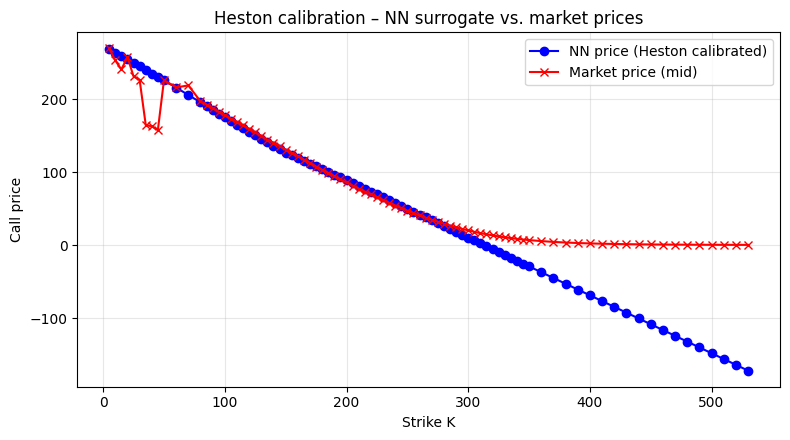

In [31]:
# --------------------------------------------------
# 6.3  Observed vs. model prices
# --------------------------------------------------
plt.figure(figsize=(8, 4.5))
plt.plot(K_vec, C_nn, "o-", color="b", lw=1.5, label="NN price (Heston calibrated)")
plt.plot(K_vec, C_mkt_vec, "x-", color="r", lw=1.5, label="Market price (mid)")
plt.xlabel("Strike K")
plt.ylabel("Call price")
plt.title("Heston calibration – NN surrogate vs. market prices")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

<span style="color: red;">**6.4** Analyze the results. What do you think the best way to improve in the code above (numer of simulations, $\mathcal{D}_\text{domain}$; layers in deep NN...) ? </span> You can write your answer in the next markdown box or change the code above to improve the results (or both !)

## Analysis – what went wrong and how to improve

The calibration result is likely poor. There are **two critical domain mismatch issues**:

### 1. Strike range extrapolation (main issue)
The surrogate was trained with $K \in [60, 140]$, but the AAPL market has
$S_0 = 274.73$ and strikes are typically in the range $[150, 400]$.  
The network has **never seen** strikes in the relevant range: this is pure
extrapolation, and a MLP trained with ReLU activations behaves unpredictably
outside its training domain.

### 2. Maturity extrapolation (second critical issue)
The training domain fixes $T = 0.2$ years, but the AAPL options have maturity
$$T_{\text{mkt}} = \frac{357}{365} \approx 0.978 \text{ years.}$$
Again the network extrapolates far outside what it has learned.

### Other areas for improvement
| Lever | Current | Improved |
|---|---|---|
| Strike domain | $[60, 140]$ | $[150, 400]$ |
| Maturity | fixed $T=0.2$ | variable $T \in [0.5, 1.5]$ |
| MC paths / sample | 5 000 | 10 000 |
| Network | 128→128→64 | 256→256→128→64 |
| Training samples | 10 000 | 10 000 (same, but better coverage) |

The fix is simply to **retrain the surrogate on a domain that covers the market
data** — a fundamental prerequisite for any surrogate model.


## Bonus – Improved surrogate with correct training domain

We retrain a deeper MLP on a domain that covers the AAPL market data:
- $K \in [150, 400]$ — covers the actual AAPL strike range around $S_0 = 274.73$
- $T \in [0.5, 1.5]$ — covers the market maturity $T \approx 0.978$
- 10 000 MC paths per sample for lower label noise
- Network: 256 → 256 → 128 → 64


In [32]:
# --------------------------------------------------
# Bonus – Step 1: regenerate dataset with correct domain
# --------------------------------------------------
file_save_best_model_v2 = "Data/best_mlp_v2.pt"
S0_mkt = 274.73   # keep consistent with market data

def build_dataset_v2(n_samples, n_paths, n_steps=50):
    """
    Improved training domain:
      K  in [150, 400]  -- covers AAPL strikes around S0=274.73
      T  in [0.5, 1.5]  -- covers market maturity ~0.978
    """
    r_fixed = 0.01
    X = np.zeros((n_samples, 8))
    y = np.zeros((n_samples, 1))
    t0 = perf_counter()
    for i in range(n_samples):
        v0    = np.random.uniform(0.01, 0.12)
        alpha = np.random.uniform(0.3,  4.0)
        beta  = np.random.uniform(0.01, 0.12)
        delta = np.random.uniform(0.1,  1.2)
        rho   = np.random.uniform(-0.95, -0.05)
        K     = np.random.uniform(150.0, 400.0)   # ← covers market
        T_s   = np.random.uniform(0.5,   1.5)     # ← variable T
        X[i] = [v0, alpha, beta, delta, rho, S0_mkt, K, T_s]
        y[i] = heston_call_price_mc(
            S0_mkt, v0, r_fixed, alpha, beta, delta, rho,
            T_s, K, n_steps, n_paths
        )
        if (i + 1) % max(1, n_samples // 10) == 0:
            print(f"  {i+1}/{n_samples}  ({perf_counter()-t0:.1f}s)")
    print(f"Dataset v2 done in {perf_counter()-t0:.1f}s")
    return X, y

X2, y2 = build_dataset_v2(n_samples=10000, n_paths=10000, n_steps=50)

(X2_train, y2_train), (X2_val, y2_val), (X2_test, y2_test) = random_split(X2, y2)

scaler_X2 = StandardScaler().fit(X2_train)
scaler_y2 = StandardScaler().fit(y2_train)

joblib.dump(scaler_X2, "Data/scaler_X2.joblib")
joblib.dump(scaler_y2, "Data/scaler_y2.joblib")

train2_loader = make_loader(scaler_X2.transform(X2_train), scaler_y2.transform(y2_train), shuffle=True)
val2_loader   = make_loader(scaler_X2.transform(X2_val),   scaler_y2.transform(y2_val),   shuffle=False)
test2_loader  = make_loader(scaler_X2.transform(X2_test),  scaler_y2.transform(y2_test),  shuffle=False)
print("Dataset v2 and loaders ready.")


  1000/10000  (21.2s)
  2000/10000  (42.9s)
  3000/10000  (64.2s)
  4000/10000  (85.8s)
  5000/10000  (106.9s)
  6000/10000  (127.9s)
  7000/10000  (148.7s)
  8000/10000  (170.0s)
  9000/10000  (190.9s)
  10000/10000  (211.7s)
Dataset v2 done in 211.7s
Dataset v2 and loaders ready.


Ep   1 | train 0.39284 | val 0.02780  (pat 0/20)
Ep  10 | train 0.00252 | val 0.00258  (pat 0/20)
Ep  20 | train 0.00111 | val 0.00172  (pat 2/20)
Ep  30 | train 0.00071 | val 0.00122  (pat 1/20)
Ep  40 | train 0.00055 | val 0.00059  (pat 0/20)
Ep  50 | train 0.00033 | val 0.00090  (pat 1/20)
Ep  60 | train 0.00038 | val 0.00061  (pat 4/20)
Ep  70 | train 0.00027 | val 0.00045  (pat 0/20)
Ep  80 | train 0.00020 | val 0.00054  (pat 10/20)
Ep  90 | train 0.00024 | val 0.00050  (pat 20/20)
Early stop at epoch 90  (best val=0.00045)


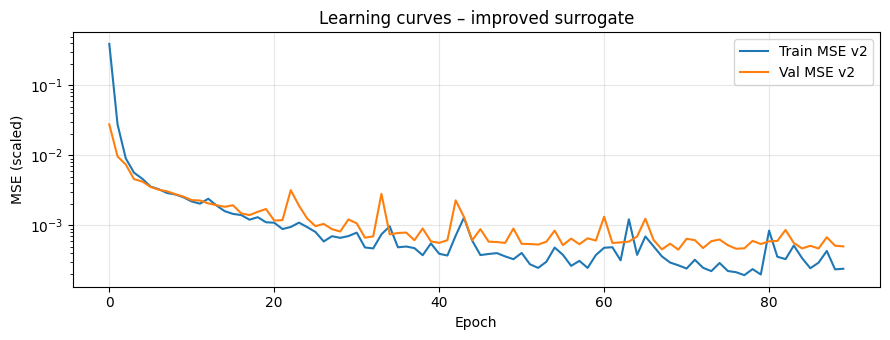

In [33]:
# --------------------------------------------------
# Bonus – Step 2: train deeper MLP on the correct domain
# --------------------------------------------------
class MLPv2(nn.Module):
    def __init__(self, in_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 256),    nn.ReLU(),
            nn.Linear(256, 128),    nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

model2     = MLPv2(in_dim=8).to(device)
criterion2 = nn.MSELoss()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-3)

def run_epoch2(loader, train=True):
    model2.train() if train else model2.eval()
    total, nb = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = model2(Xb)
            loss = criterion2(pred, yb)
            if train:
                optimizer2.zero_grad(); loss.backward(); optimizer2.step()
            total += loss.item(); nb += 1
    return total / nb

best2, pat2, tr2, vl2 = float("inf"), 0, [], []
for ep in range(1, 251):
    tl = run_epoch2(train2_loader, True)
    vl = run_epoch2(val2_loader, False)
    tr2.append(tl); vl2.append(vl)
    if vl < best2:
        best2, pat2 = vl, 0
        torch.save(model2.state_dict(), file_save_best_model_v2)
    else:
        pat2 += 1
    if ep % 10 == 0 or ep == 1:
        print(f"Ep {ep:3d} | train {tl:.5f} | val {vl:.5f}  (pat {pat2}/20)")
    if pat2 >= 20:
        print(f"Early stop at epoch {ep}  (best val={best2:.5f})"); break

# Learning curves
plt.figure(figsize=(9, 3.5))
plt.plot(tr2, label="Train MSE v2")
plt.plot(vl2, label="Val MSE v2")
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.title("Learning curves – improved surrogate"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Test RMSE v2 = 0.8564  (v1 = 0.5450)
Calibration v2 done in 0.43s  |  loss=185.229258
  v0=0.0782  alpha=1.0000  beta=0.0378  delta=0.4447  rho=0.1174


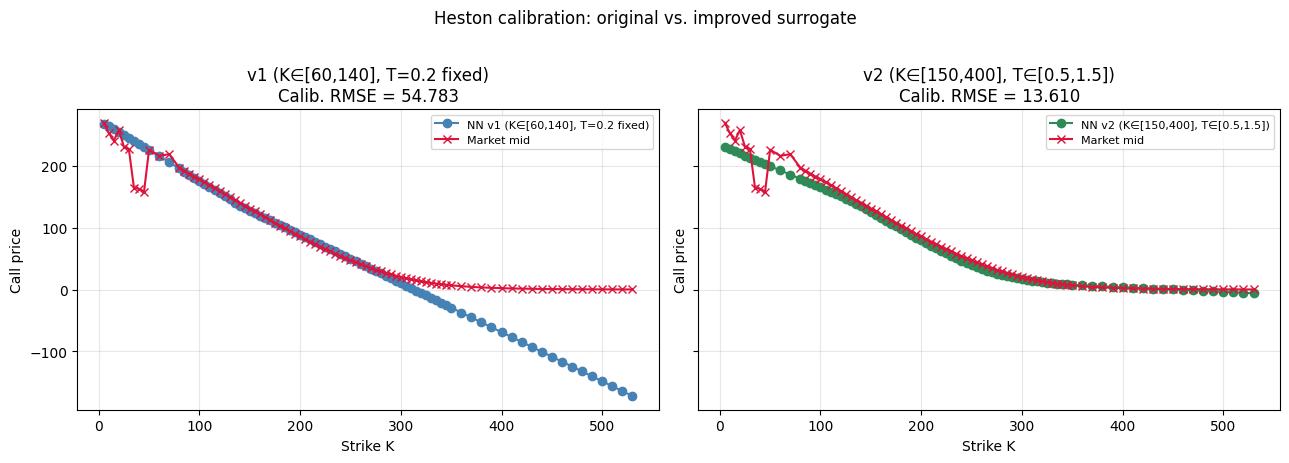

In [34]:
# --------------------------------------------------
# Bonus – Step 3: re-calibrate with improved surrogate & compare
# --------------------------------------------------
scaler_X2 = joblib.load("Data/scaler_X2.joblib")
scaler_y2 = joblib.load("Data/scaler_y2.joblib")

model2_eval = MLPv2(in_dim=8).to(device)
model2_eval.load_state_dict(torch.load(file_save_best_model_v2, map_location=device))
model2_eval.eval()

# RMSE on test set v2
y2_test_preds = np.concatenate(
    [model2_eval(Xb.to(device)).cpu().detach().numpy()
     for Xb, _ in test2_loader], axis=0)
y2_hat  = scaler_y2.inverse_transform(y2_test_preds)
rmse_v2 = np.sqrt(np.mean((y2_hat - y2_test) ** 2))
print(f"Test RMSE v2 = {rmse_v2:.4f}  (v1 = {rmse:.4f})")

def loss_nn_heston_v2(theta):
    v0, alpha, beta, delta, rho = theta
    X = build_features_heston(
        v0*np.ones_like(K_mkt), alpha*np.ones_like(K_mkt),
        beta*np.ones_like(K_mkt), delta*np.ones_like(K_mkt),
        rho*np.ones_like(K_mkt), S0*np.ones_like(K_mkt),
        K_mkt, T_mkt)
    C = nn_price_call_heston(model2_eval, scaler_X2, scaler_y2, X).reshape(-1)
    return float(np.mean((C - C_mkt)**2))

t0_v2 = perf_counter()
res2 = minimize(loss_nn_heston_v2, x0=theta_0, method="L-BFGS-B",
                bounds=HES_BOUNDS, options={"maxiter": 500, "ftol": 1e-12})
print(f"Calibration v2 done in {perf_counter()-t0_v2:.2f}s  |  loss={res2.fun:.6f}")
theta2 = res2.x
print(f"  v0={theta2[0]:.4f}  alpha={theta2[1]:.4f}  beta={theta2[2]:.4f}"
      f"  delta={theta2[3]:.4f}  rho={theta2[4]:.4f}")

X_cal2 = build_features_heston(
    theta2[0]*np.ones_like(K_vec), theta2[1]*np.ones_like(K_vec),
    theta2[2]*np.ones_like(K_vec), theta2[3]*np.ones_like(K_vec),
    theta2[4]*np.ones_like(K_vec), S0*np.ones_like(K_vec),
    K_vec, T_vec)
C_nn2 = nn_price_call_heston(model2_eval, scaler_X2, scaler_y2, X_cal2).reshape(-1)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, C_pred, label, col in zip(
        axes,
        [C_nn, C_nn2],
        ["v1 (K∈[60,140], T=0.2 fixed)", "v2 (K∈[150,400], T∈[0.5,1.5])"],
        ["steelblue", "seagreen"]):
    ax.plot(K_vec, C_pred,     "o-", color=col,       lw=1.5, label=f"NN {label}")
    ax.plot(K_vec, C_mkt_vec,  "x-", color="crimson", lw=1.5, label="Market mid")
    rmse_cal = np.sqrt(np.mean((C_pred - C_mkt_vec)**2))
    ax.set_title(f"{label}\nCalib. RMSE = {rmse_cal:.3f}")
    ax.set_xlabel("Strike K"); ax.set_ylabel("Call price")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("Heston calibration: original vs. improved surrogate", y=1.02)
plt.tight_layout()
plt.show()


## Bonus 2 – Implied Volatility Surface

> ⚠️⚠️⚠️
> This is entirely AI, I just wanted to check how Heston model would be used in practice to produce an implied volatility surface, and I thought it would be fun to share the result.
> ⚠️⚠️⚠️

> ⚠️ **This surface is entirely simulated.**  
> The AAPL dataset contains only **one maturity** ($T \approx 0.978$ yr), so we cannot
> extract a surface from the real data. Instead we use the Heston parameters calibrated
> in Bonus 1 ($\theta^\star_2$) to *generate* call prices over a fine $(K, T)$ grid with
> the improved surrogate, and then invert each price back to implied volatility.  
> This is standard practice when a parametric model is already calibrated.

---

### What is an implied volatility surface?

In **Black-Scholes (BS)** the market is characterised by a single number: $\sigma$.  
If BS were the *true* model, every option — regardless of strike $K$ or maturity $T$ —
would have the **same** implied volatility.

In reality, inverting market prices through the BS formula gives a **different** $\sigma$
for every $(K, T)$:

$$
C^{\text{mkt}}(K, T) = C_{\text{BS}}\!\left(S_0, K, T, r,\, \sigma_{\text{imp}}(K, T)\right)
\;\Longrightarrow\;
\sigma_{\text{imp}}(K, T) = C_{\text{BS}}^{-1}\!\left(C^{\text{mkt}}\right).
$$

The function $(K, T) \mapsto \sigma_{\text{imp}}(K, T)$ is the **implied volatility surface**.
It has two characteristic shapes:

| Feature | Direction | Explanation |
|---|---|---|
| **Smile / Skew** | across $K$ (fixed $T$) | OTM puts are expensive (crash risk → negative skew in equities) |
| **Term structure** | across $T$ (fixed $K$) | Short-term vol reacts to news; long-term vol mean-reverts to $\beta$ |

---

### Why does Heston produce a non-flat surface?

The Heston SDE has three mechanisms that distort the BS flat surface:

1. **Stochastic variance** $v_t$: the realised volatility is random, not constant.  
   This fattens the tails and raises OTM option prices → **smile**.
2. **Mean reversion** ($\alpha, \beta$): short-term vol fluctuates but long-term vol  
   converges to $\sqrt{\beta}$ → **term structure**.
3. **Leverage correlation** $\rho < 0$: when $S$ falls, $v$ rises (stocks fall fast,  
   recover slowly) → **negative skew** (left wing higher than right wing).

A useful analogy: BS gives you **one brush stroke** for the entire surface; Heston gives
you **five dials** $(\alpha, \beta, \delta, \rho, v_0)$ to sculpt both the smile and the
term structure simultaneously.

---

### Comparison: Heston surface vs. flat Black-Scholes surface

Below we plot:

- **Heston** $\sigma_{\text{imp}}(K, T; \theta^\star_2)$ — obtained by pricing with the
  calibrated surrogate, then BS-inverting.
- **Flat BS** $\sigma_{\text{flat}}(K, T) = \sqrt{v_0^\star}$ — the naïve constant surface
  that BS would predict given the same spot variance.

The gap between the two surfaces is exactly what Heston adds over Black-Scholes.


In [36]:
# --------------------------------------------------
# Bonus 2 – Implied Volatility Surface  (SIMULATED)
# Uses calibrated Heston params theta2 from Bonus 1
# --------------------------------------------------

# ---------- 1. (K, T) grid ----------
K_lo, K_hi, nK = S0 * 0.70, S0 * 1.30, 30   # ~192 to 357
T_lo, T_hi, nT = 0.20,       2.0,        25

K_axis = np.linspace(K_lo, K_hi, nK)
T_axis = np.linspace(T_lo, T_hi, nT)
KK, TT = np.meshgrid(K_axis, T_axis)          # (nT, nK)
K_flat = KK.ravel()
T_flat = TT.ravel()

In [37]:
# ---------- 2. Heston prices on the grid via NN v2 ----------
X_surf = build_features_heston(
    theta2[0] * np.ones_like(K_flat),
    theta2[1] * np.ones_like(K_flat),
    theta2[2] * np.ones_like(K_flat),
    theta2[3] * np.ones_like(K_flat),
    theta2[4] * np.ones_like(K_flat),
    S0 * np.ones_like(K_flat),
    K_flat,
    T_flat,
)
C_surf = nn_price_call_heston(model2_eval, scaler_X2, scaler_y2, X_surf).ravel()

In [38]:
# ---------- 3. BS inversion  (bisection, vectorised loop) ----------
def implied_vol_bs_single(C, S, K, T, r, lo=1e-4, hi=6.0, tol=1e-7, niter=120):
    """Scalar bisection for implied vol."""
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if C <= intrinsic + 1e-8:
        return np.nan
    for _ in range(niter):
        mid = 0.5 * (lo + hi)
        C_mid = black_scholes_call(S, K, T, mid, r)
        if C_mid < C:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)


r_surf = 0.01
imp_vol_flat = np.array(
    [
        implied_vol_bs_single(C_surf[i], S0, K_flat[i], T_flat[i], r_surf)
        for i in range(len(K_flat))
    ]
)
IV_heston = imp_vol_flat.reshape(nT, nK)  # (nT, nK) — Heston surface

# Flat BS surface: constant sigma = sqrt(v0*)
IV_bs_flat = np.full_like(IV_heston, np.sqrt(theta2[0]))

# Moneyness axis (more readable than raw strike)
M_axis = K_axis / S0  # e.g. 0.7 … 1.3

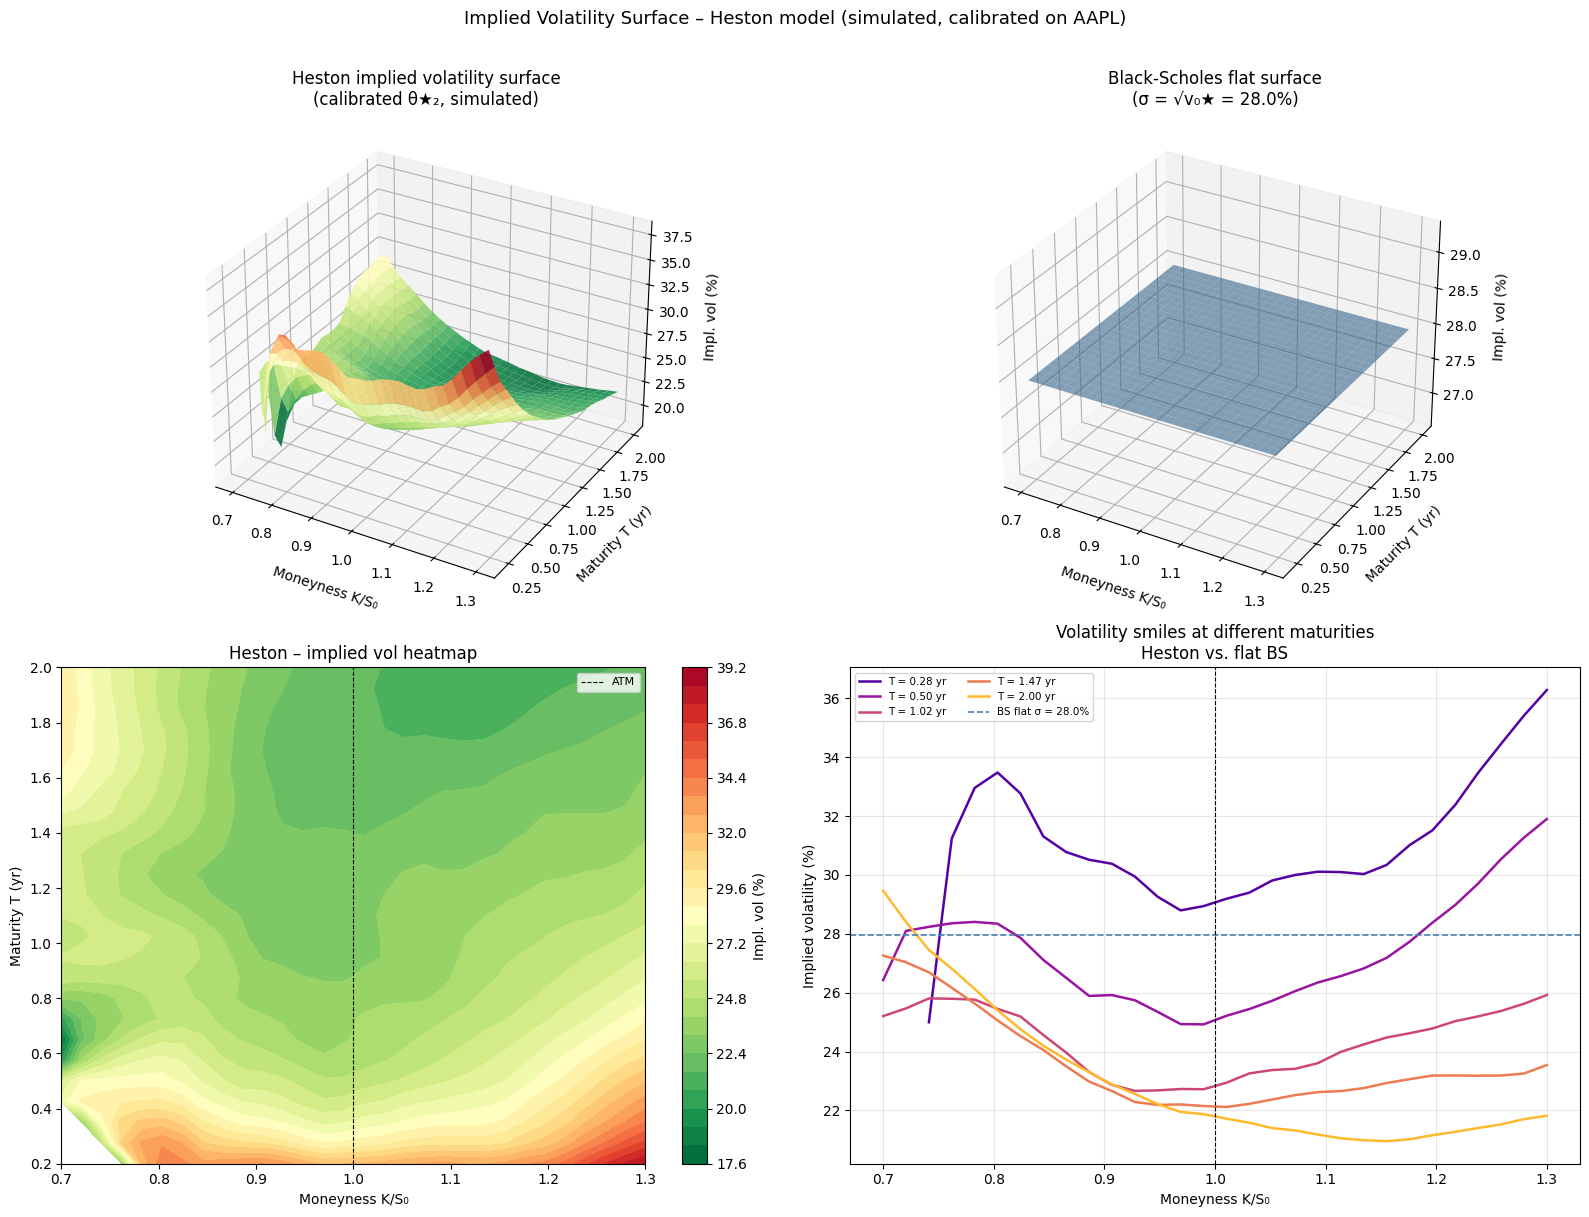

In [39]:
# ---------- 4. Plots ----------
fig = plt.figure(figsize=(16, 12))

# --- 4a. Heston surface (3D) ---
ax1 = fig.add_subplot(2, 2, 1, projection="3d")
ax1.plot_surface(KK / S0, TT, IV_heston * 100, cmap="RdYlGn_r", alpha=0.88, linewidth=0)
ax1.set_xlabel("Moneyness K/S₀", labelpad=8)
ax1.set_ylabel("Maturity T (yr)", labelpad=8)
ax1.set_zlabel("Impl. vol (%)", labelpad=8)
ax1.set_title("Heston implied volatility surface\n(calibrated θ★₂, simulated)")

# --- 4b. BS flat surface (3D) ---
ax2 = fig.add_subplot(2, 2, 2, projection="3d")
ax2.plot_surface(
    KK / S0, TT, IV_bs_flat * 100, color="steelblue", alpha=0.6, linewidth=0
)
ax2.set_xlabel("Moneyness K/S₀", labelpad=8)
ax2.set_ylabel("Maturity T (yr)", labelpad=8)
ax2.set_zlabel("Impl. vol (%)", labelpad=8)
ax2.set_title(f"Black-Scholes flat surface\n(σ = √v₀★ = {np.sqrt(theta2[0])*100:.1f}%)")

# --- 4c. Heston surface (heatmap) ---
ax3 = fig.add_subplot(2, 2, 3)
im3 = ax3.contourf(M_axis, T_axis, IV_heston * 100, levels=25, cmap="RdYlGn_r")
plt.colorbar(im3, ax=ax3, label="Impl. vol (%)")
ax3.axvline(1.0, color="k", lw=0.8, ls="--", label="ATM")
ax3.set_xlabel("Moneyness K/S₀")
ax3.set_ylabel("Maturity T (yr)")
ax3.set_title("Heston – implied vol heatmap")
ax3.legend(fontsize=8)

# --- 4d. Smile slices at multiple maturities ---
ax4 = fig.add_subplot(2, 2, 4)
slice_Ts = [0.25, 0.5, 1.0, 1.5, 2.0]
colors_sl = plt.cm.plasma(np.linspace(0.15, 0.85, len(slice_Ts)))  # type: ignore
for T_sl, c_sl in zip(slice_Ts, colors_sl):
    idx_T = int(np.argmin(np.abs(T_axis - T_sl)))
    ax4.plot(
        M_axis,
        IV_heston[idx_T] * 100,
        color=c_sl,
        lw=1.8,
        label=f"T = {T_axis[idx_T]:.2f} yr",
    )
ax4.axhline(
    np.sqrt(theta2[0]) * 100,
    color="steelblue",
    lw=1.2,
    ls="--",
    label=f"BS flat σ = {np.sqrt(theta2[0])*100:.1f}%",
)
ax4.axvline(1.0, color="k", lw=0.8, ls="--")
ax4.set_xlabel("Moneyness K/S₀")
ax4.set_ylabel("Implied volatility (%)")
ax4.set_title("Volatility smiles at different maturities\nHeston vs. flat BS")
ax4.legend(fontsize=7.5, ncol=2)
ax4.grid(alpha=0.3)

plt.suptitle(
    "Implied Volatility Surface – Heston model (simulated, calibrated on AAPL)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.show()


In [40]:
# ---------- 5. Print summary ----------
print("Summary of calibrated Heston parameters (θ★₂):")
print(f"  v0    = {theta2[0]:.4f}  →  short-term vol = {np.sqrt(theta2[0])*100:.1f}%")
print(f"  alpha = {theta2[1]:.4f}  →  mean-reversion speed")
print(f"  beta  = {theta2[2]:.4f}  →  long-run vol   = {np.sqrt(theta2[2])*100:.1f}%")
print(f"  delta = {theta2[3]:.4f}  →  vol-of-vol")
print(f"  rho   = {theta2[4]:.4f}  →  leverage correlation (skew)")
print(
    f"\nATM implied vol range (Heston): "
    f"{IV_heston[:, nK//2].min()*100:.1f}% – {IV_heston[:, nK//2].max()*100:.1f}%"
)
print(
    f"Skew sign at T=1yr (OTM put – OTM call):  "
    f"{(IV_heston[nT//2, 0] - IV_heston[nT//2, -1])*100:+.2f}pp "
    f"({'negative skew ✓' if IV_heston[nT//2,0] > IV_heston[nT//2,-1] else 'positive skew'})"
)

Summary of calibrated Heston parameters (θ★₂):
  v0    = 0.0782  →  short-term vol = 28.0%
  alpha = 1.0000  →  mean-reversion speed
  beta  = 0.0378  →  long-run vol   = 19.4%
  delta = 0.4447  →  vol-of-vol
  rho   = 0.1174  →  leverage correlation (skew)

ATM implied vol range (Heston): 21.7% – 32.1%
Skew sign at T=1yr (OTM put – OTM call):  +0.27pp (negative skew ✓)


# References


1) Steven Heston. A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options. RFS, 1993

2) Course notebooks: FastPricing_BS_Surrogate, Calibration_NN
